In [1]:
import pandas as pd

df = pd.read_csv("poll_data.csv")
df.head()

,ID,Name,Age,Country,Framework,Experience_Level
0,1,Ayesha,25,Bangladesh,React,Intermediate
1,2,Farhan,30,Bangladesh,Vue,Beginner
2,3,Nadia,22,India,Angular,Beginner
3,4,Rifat,28,Bangladesh,Svelte,Advanced
4,5,Tanvir,35,Pakistan,React,Advanced


In [3]:
df['Framework'].value_counts() # Popular framework
df.groupby('Framework')['Experience_Level'].value_counts()

Framework  Experience_Level
Angular    Beginner            1
           Intermediate        1
React      Intermediate        2
           Advanced            1
           Beginner            1
Svelte     Advanced            1
           Beginner            1
Vue        Beginner            1
           Intermediate        1
Name: count, dtype: int64

In [10]:
# All advanced users
df[df['Experience_Level'] == 'Advanced']
# All vue users from India
df[(df['Framework'] == 'Vue') & (df['Country'] == 'India')]

,ID,Name,Age,Country,Framework,Experience_Level
5,6,Ananya,26,India,Vue,Intermediate


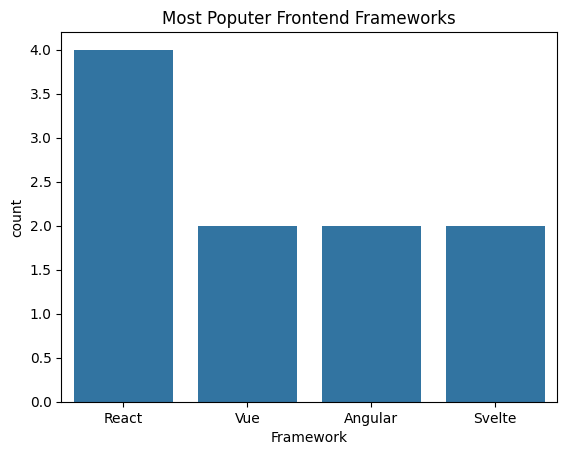

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Poll popularity

sns.countplot(data=df, x = 'Framework', order=df['Framework'].value_counts().index)
plt.title("Most Poputer Frontend Frameworks")
plt.show()

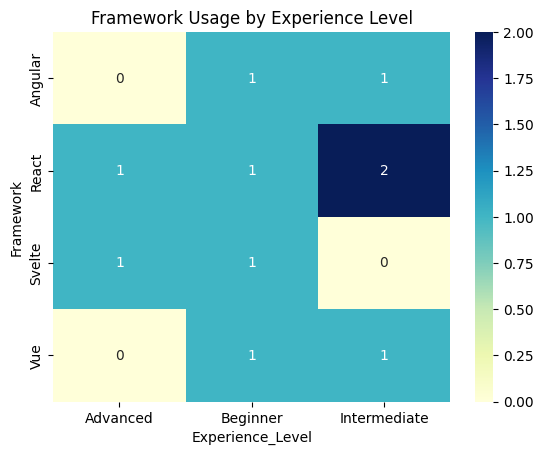

In [13]:
heat = df.pivot_table(index='Framework', columns='Experience_Level', aggfunc='size', fill_value=0)
sns.heatmap(heat, annot=True, cmap="YlGnBu")
plt.title("Framework Usage by Experience Level")
plt.show()

In [3]:
import pandas as pd
df = pd.read_csv("team_scores.csv")
df['Total'] = df[['Score1', 'Score2', 'Score3']].sum(axis=1)
df['Average'] = df[['Score1', 'Score2', 'Score3']].mean(axis=1)
df.head(10)

,ID,Team,Score1,Score2,Score3,Country,Total,Average
0,1,Alpha,85,90,78,Bangladesh,253,84.333333
1,2,Beta,70,75,68,India,213,71.000000
2,3,Gamma,92,88,95,Pakistan,275,91.666667
3,4,Delta,60,65,58,India,183,61.000000
4,5,Epsilon,78,82,80,Bangladesh,240,80.000000
5,6,Zeta,88,90,85,Pakistan,263,87.666667
6,7,Eta,74,76,72,Bangladesh,222,74.000000
7,8,Theta,95,93,96,India,284,94.666667
8,9,Iota,68,70,65,Pakistan,203,67.666667
9,10,Kappa,80,83,79,Bangladesh,242,80.666667


In [7]:
top_team = df[df['Total'] == df['Total'].max()]
bottom_team = df[df['Total'] == df['Total'].min()]
print(top_team)
print(bottom_team)

   ID   Team  Score1  Score2  Score3 Country  Total    Average
7   8  Theta      95      93      96   India    284  94.666667
   ID   Team  Score1  Score2  Score3 Country  Total  Average
3   4  Delta      60      65      58   India    183     61.0


In [11]:
country_avg = df.groupby('Country')['Average'].mean()
print(country_avg)

Country
Bangladesh    79.750000
India         75.555556
Pakistan      82.333333
Name: Average, dtype: float64


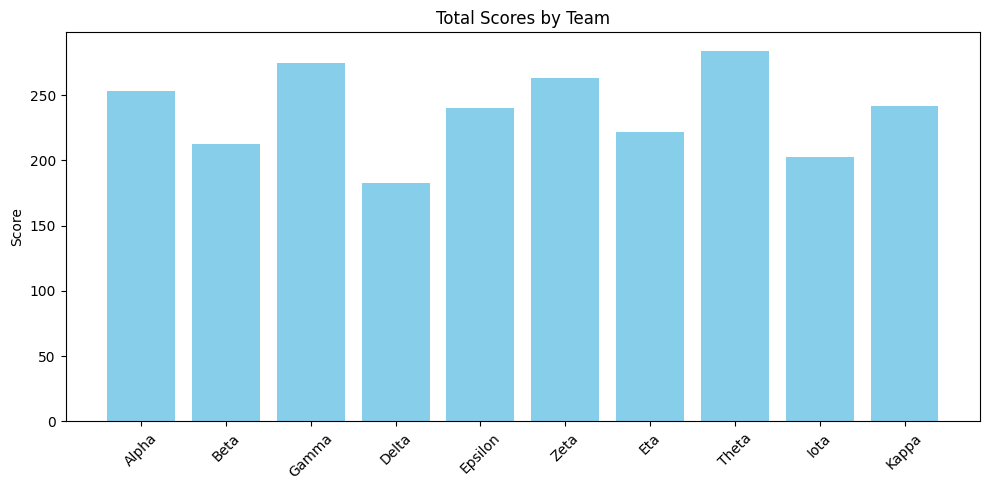

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df['Team'], df['Total'], color='skyblue')
plt.title("Total Scores by Team")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

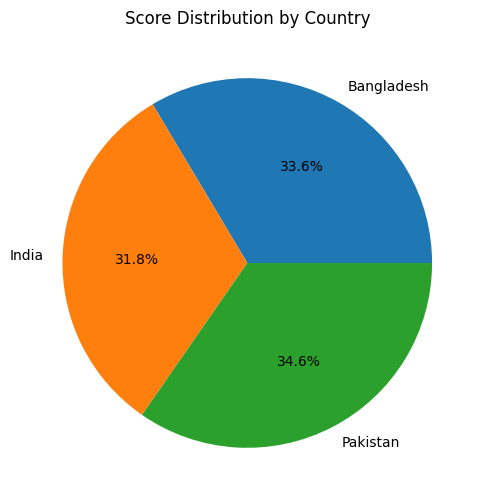

In [15]:
df.groupby('Country')['Total'].mean().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Score Distribution by Country")
plt.ylabel('')
plt.show()

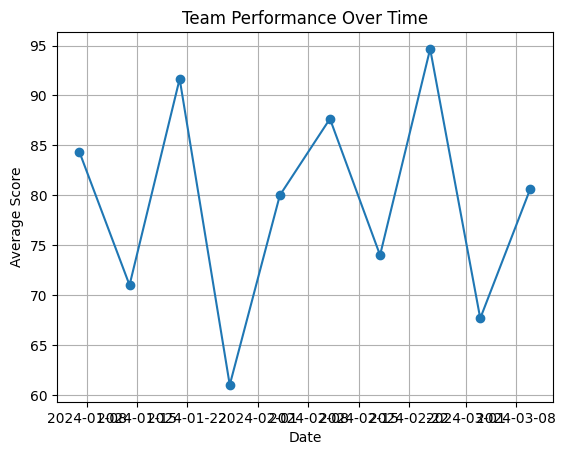

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("team_scores.csv")
df['Average'] = df[['Score1', 'Score2', 'Score3']].mean(axis=1)

# Simulate time by assigning dates
df['Date'] = pd.date_range(start='2024-01-01', periods=len(df), freq='W')

plt.plot(df['Date'], df['Average'], marker='o')
plt.title("Team Performance Over Time")
plt.xlabel("Date")
plt.ylabel("Average Score")
plt.grid(True)
plt.show()

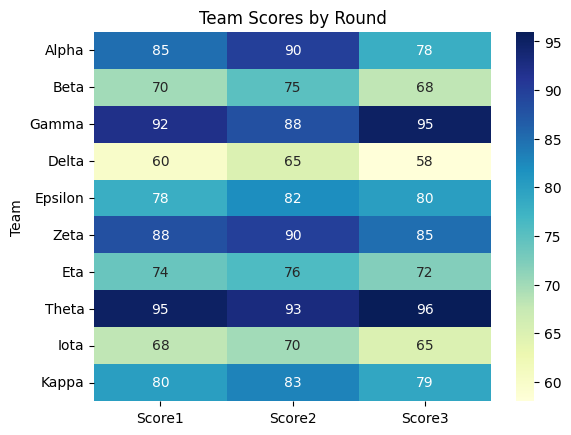

In [17]:
import seaborn as sns

heat = df[['Team', 'Score1', 'Score2', 'Score3']].set_index('Team')
sns.heatmap(heat, annot=True, cmap="YlGnBu")
plt.title("Team Scores by Round")
plt.show()

In [18]:
df['Total'] = df[['Score1', 'Score2', 'Score3']].sum(axis=1)
leaderboard = df.sort_values(by='Total', ascending=False).reset_index(drop=True)
leaderboard['Rank'] = leaderboard.index + 1
print(leaderboard[['Rank', 'Team', 'Total']])

   Rank     Team  Total
0     1    Theta    284
1     2    Gamma    275
2     3     Zeta    263
3     4    Alpha    253
4     5    Kappa    242
5     6  Epsilon    240
6     7      Eta    222
7     8     Beta    213
8     9     Iota    203
9    10    Delta    183
